In [1]:
import os
os.chdir("../../..")
print(os.getcwd())

/Users/titonka/FAIRIS


In [13]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from heapq import heappush, heappop

def parse_world(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    walls = []
    landmarks = []
    experiment_starts = []
    habituation_starts = []
    goal = None

    for child in root:
        if child.tag == 'wall':
            x1, y1 = float(child.attrib['x1']), float(child.attrib['y1'])
            x2, y2 = float(child.attrib['x2']), float(child.attrib['y2'])
            walls.append(((x1, y1), (x2, y2)))

        elif child.tag == 'landmark':
            x = float(child.attrib['x'])
            y = float(child.attrib['y'])
            color = (
                float(child.attrib['red']),
                float(child.attrib['green']),
                float(child.attrib['blue'])
            )
            landmarks.append((x, y, color))

        elif child.tag == 'experimentStartPositions':
            for pos in child.findall('pos'):
                x = float(pos.attrib['x'])
                y = float(pos.attrib['y'])
                theta = float(pos.attrib['theta'])
                experiment_starts.append((x, y, theta))

        elif child.tag == 'habituationStartPositions':
            for pos in child.findall('pos'):
                x = float(pos.attrib['x'])
                y = float(pos.attrib['y'])
                theta = float(pos.attrib['theta'])
                habituation_starts.append((x, y, theta))

        elif child.tag == 'goal':
            goal = (float(child.attrib['x']), float(child.attrib['y']))

    return walls, landmarks, experiment_starts, habituation_starts, goal


def plot_world(walls, landmarks, experiment_starts, habituation_starts, goal, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot walls
    for (x1, y1), (x2, y2) in walls:
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=2)

    # Plot landmarks
    for x, y, color in landmarks:
        ax.scatter(x, y, color=[color], s=150, marker='o', edgecolors='k', label='Landmark')

    # Plot experiment start positions as green diamonds
    for x, y, theta in experiment_starts:
        ax.scatter(x, y, color='green', s=100, marker='D', edgecolors='black', label='Start')
    
    # Plot habituation start positions as green diamonds
    for x, y, theta in habituation_starts:
        ax.scatter(x, y, color='green', s=100, marker='D', edgecolors='black', label='Start')


    # Plot goal
    if goal:
        ax.scatter(goal[0], goal[1], color='red', s=200, marker='*', edgecolors='black', label='Goal')

    # Style plot
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Parsed World Map from XML')

    # Avoid duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    if save_path:
        plt.savefig(save_path)
    plt.show()
   


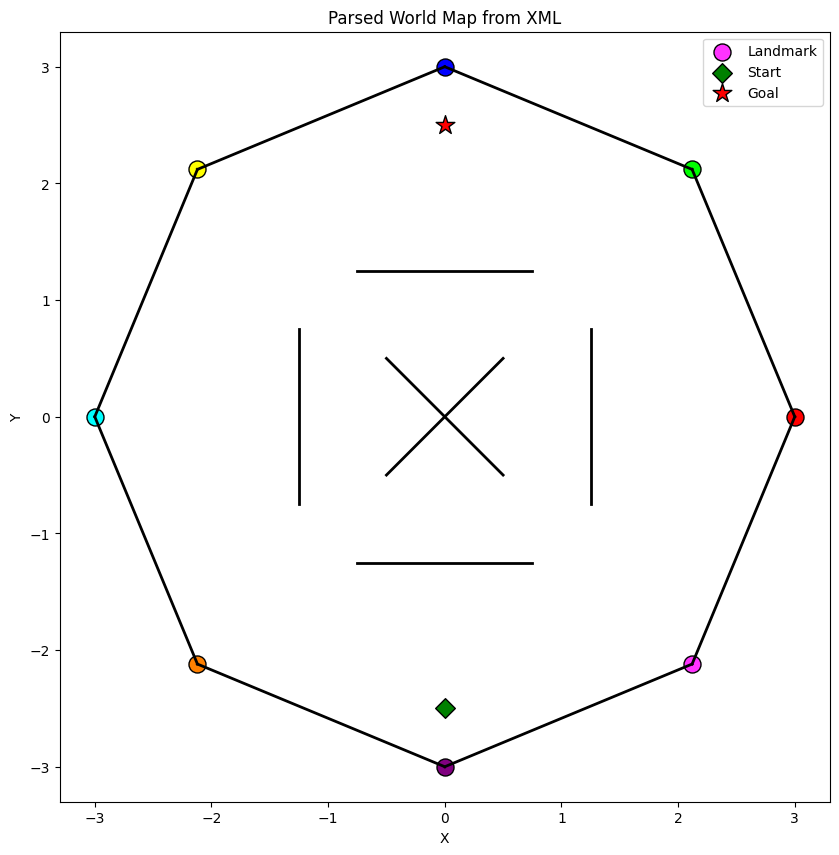

In [14]:
xml_path = "simulation/worlds/mazes/VisualPlaceCells/LMO8.xml"  # Replace with your actual XML file
walls, landmarks, exp_starts, hab_starts, goal = parse_world(xml_path)
plot_world(walls, landmarks, exp_starts, hab_starts, goal)


In [19]:
def plot_random_pc_activation(num_pcs=25, seed=None, save_path=None):
    """
    Generate and plot a random normalized place cell activation bar graph.
    
    Args:
        num_pcs (int): Number of place cells to simulate.
        seed (int, optional): Random seed for reproducibility.
        save_path (str, optional): If provided, saves the plot to this file.
    """
    if seed is not None:
        np.random.seed(seed)

    # Generate raw random activations
    raw_activations = np.random.rand(num_pcs)

    # Min-max normalize
    min_val = np.min(raw_activations)
    max_val = np.max(raw_activations)
    if max_val > min_val:
        activations = (raw_activations - min_val) / (max_val - min_val)
    else:
        activations = np.zeros_like(raw_activations)

    # Bar labels: PC 1, PC 2, ..., PC N
    labels = [f"PC {i+1}" for i in range(num_pcs)]

    # Plot
    plt.figure(figsize=(12, 4))
    plt.bar(labels, activations, color='skyblue', edgecolor='black')
    plt.ylabel("Activation")
    plt.xlabel("Place Cells")
    plt.title(f"Place Cell Activation Pattern (n={num_pcs})")
    plt.xticks(rotation=45)

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.tight_layout()
        plt.show()


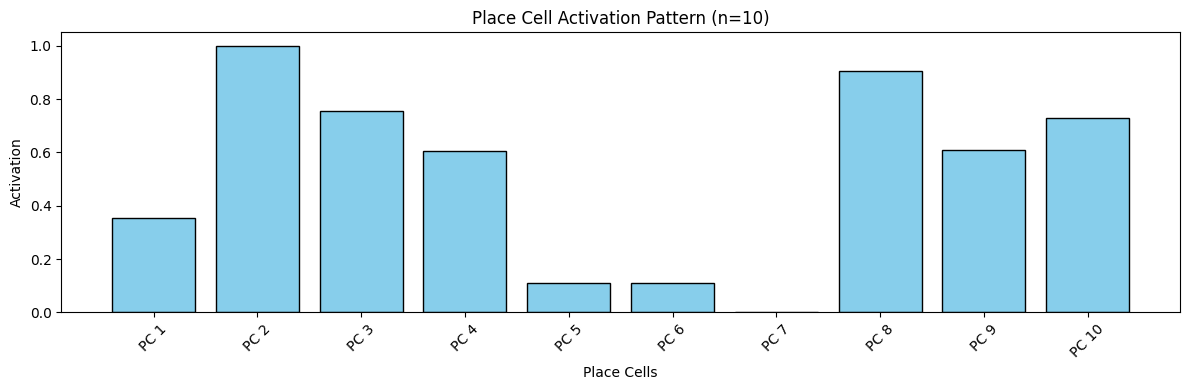

In [22]:
plot_random_pc_activation(num_pcs=10, seed=42)


In [40]:
# 8-directional motion (45-degree intervals) with step size 0.3
MOTION_DIRECTIONS = [(0.3 * np.cos(theta), 0.3 * np.sin(theta)) for theta in np.linspace(0, 2 * np.pi, 8, endpoint=False)]


def is_collision(p1, p2, walls):
    def ccw(a, b, c):
        return (c[1]-a[1]) * (b[0]-a[0]) > (b[1]-a[1]) * (c[0]-a[0])

    def segments_intersect(a1, a2, b1, b2):
        return ccw(a1, b1, b2) != ccw(a2, b1, b2) and ccw(a1, a2, b1) != ccw(a1, a2, b2)

    for wall in walls:
        if segments_intersect(p1, p2, wall[0], wall[1]):
            return True
    return False


def heuristic(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))


def a_star_8_connected(start, goal, walls):
    open_set = []
    heappush(open_set, (heuristic(start, goal), 0, start))
    came_from = {}
    cost_so_far = {start: 0}

    while open_set:
        _, cost, current = heappop(open_set)

        if heuristic(current, goal) < 0.3:
            break

        for dx, dy in MOTION_DIRECTIONS:
            next_pos = (round(current[0] + dx, 3), round(current[1] + dy, 3))

            if is_collision(current, next_pos, walls):
                continue

            new_cost = cost_so_far[current] + 0.3
            if next_pos not in cost_so_far or new_cost < cost_so_far[next_pos]:
                cost_so_far[next_pos] = new_cost
                priority = new_cost + heuristic(next_pos, goal)
                heappush(open_set, (priority, new_cost, next_pos))
                came_from[next_pos] = current

    # Reconstruct path
    path = []
    node = current
    while node != start:
        path.append(node)
        node = came_from.get(node)
        if node is None:
            return []
    path.append(start)
    path.reverse()
    return path


def plot_world_with_path(walls, landmarks, experiment_starts, habituation_starts, goal, path):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot walls
    for (x1, y1), (x2, y2) in walls:
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=2)

    # Plot landmarks
    for x, y, color in landmarks:
        ax.scatter(x, y, color=[color], s=150, marker='o', edgecolors='k', label='Landmark')

    # Plot start positions as green diamonds
    for x, y, theta in experiment_starts:
        ax.scatter(x, y, color='green', s=100, marker='D', edgecolors='black', label='Experiment Start')
    # Plot goal
    if goal:
        ax.scatter(goal[0], goal[1], color='red', s=200, marker='*', edgecolors='black', label='Goal')

    # Plot path
    if path:
        xs, ys = zip(*path)
        ax.plot(xs, ys, color='red', linewidth=2, label='Learned Path')

    # Final plot styling
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Learned Path')
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    plt.tight_layout()
    return fig


def run_a_star_pipeline(xml_path):
    walls, landmarks, experiment_starts, habituation_starts, goal = parse_world(xml_path)
    start = (experiment_starts[0][0], experiment_starts[0][1])
    path = a_star_8_connected(start, goal, walls)
    fig = plot_world_with_path(walls, landmarks, experiment_starts, habituation_starts, goal, path)
    return fig


/var/folders/k9/tcxpg_fx3d3blrkql_1z83wh0000gn/T/ipykernel_61933/1441382610.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


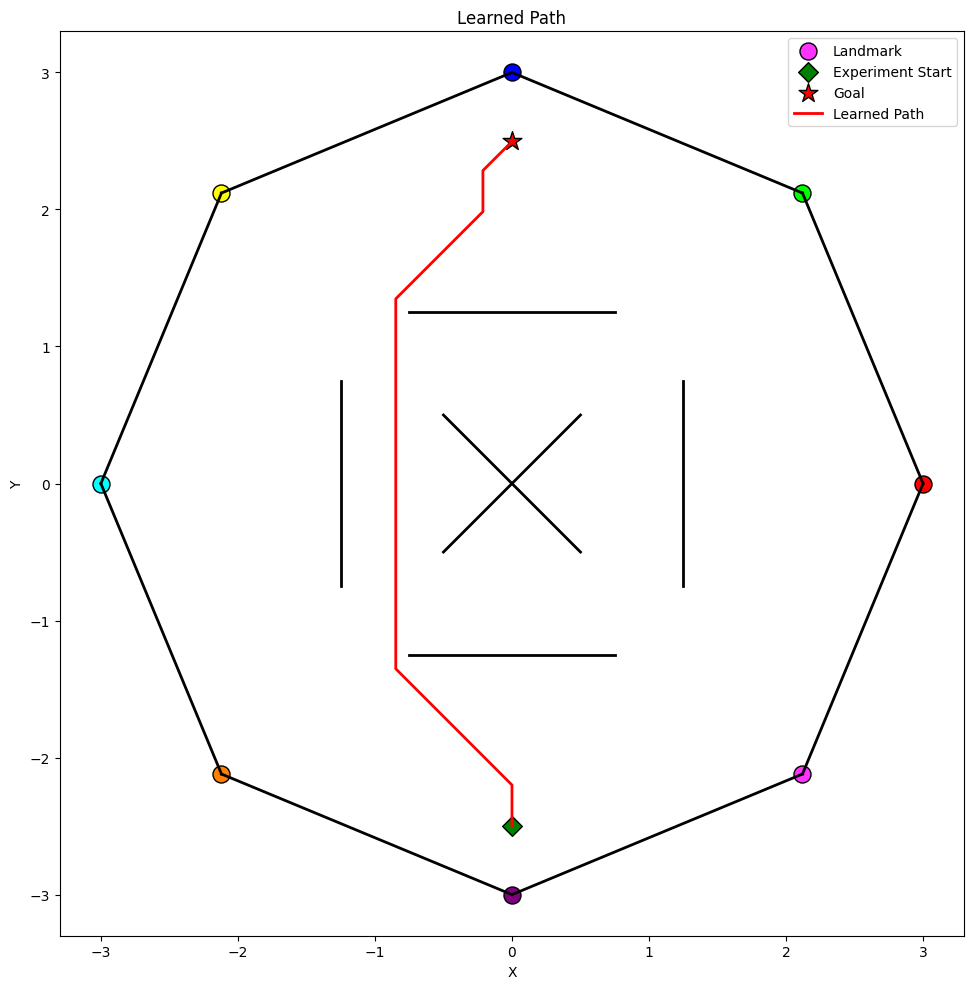

In [41]:
xml_path = "simulation/worlds/mazes/VisualPlaceCells/LMO8.xml"  # Replace with your actual XML file
fig = run_a_star_pipeline(xml_path)
fig.show()
